## 构建网络 ##
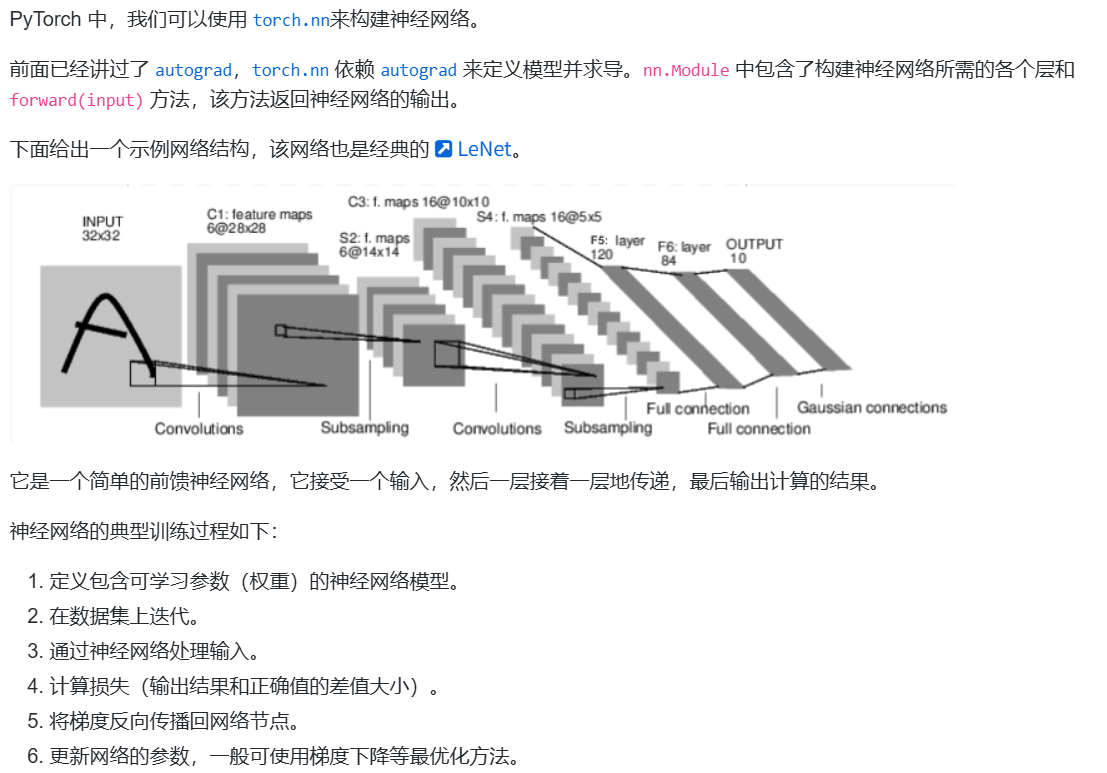

In [1]:
# 定义上图示例的神经网络结构
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 6*6 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features


net = Net()
net

Net(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

模型中必须要定义 forward 函数，backward 函数（用来计算梯度）会被 autograd 自动创建。可以在 forward 函数中使用任何针对 Tensor 的操作。

net.parameters() 返回可被学习的参数（权重）列表和值：

In [2]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight
params

10
torch.Size([6, 1, 3, 3])


[Parameter containing:
 tensor([[[[-0.2529,  0.0095,  0.1538],
           [ 0.2290,  0.2948,  0.2678],
           [-0.3254, -0.1659,  0.2232]]],
 
 
         [[[-0.1520,  0.2908,  0.2993],
           [ 0.1921,  0.1430,  0.3108],
           [-0.2175,  0.1562,  0.0669]]],
 
 
         [[[ 0.0781,  0.0667,  0.2237],
           [ 0.2571, -0.0264,  0.1309],
           [-0.2618, -0.1264, -0.0787]]],
 
 
         [[[-0.2909,  0.2889,  0.0119],
           [-0.1095, -0.1074,  0.1702],
           [-0.1733,  0.2753, -0.1052]]],
 
 
         [[[-0.2805, -0.3114,  0.0470],
           [ 0.2344,  0.2342,  0.1847],
           [-0.2437,  0.1399, -0.2639]]],
 
 
         [[[-0.2942,  0.2657, -0.3015],
           [ 0.2274, -0.3285,  0.1335],
           [-0.2058, -0.0139,  0.0597]]]], requires_grad=True),
 Parameter containing:
 tensor([ 0.0153,  0.2919, -0.0722, -0.1266, -0.2836, -0.1154],
        requires_grad=True),
 Parameter containing:
 tensor([[[[-4.3549e-02, -1.3176e-01, -1.1326e-01],
           [

测试随机输入32×32。注意，网络（LeNet）期望的输入大小是 32×32，如果使用 MNIST 数据集（28×28）来训练这个网络，注意把图片大小重新调整到32×32。

In [3]:
import torch
input = torch.randn(1, 1, 32, 32)
out = net(input)
out

tensor([[-0.0495,  0.0499,  0.1880,  0.0730,  0.0535,  0.0414,  0.0882, -0.1496,
         -0.0892,  0.0127]], grad_fn=<AddmmBackward0>)

In [4]:
net.zero_grad()
out.backward(torch.randn(1, 10))

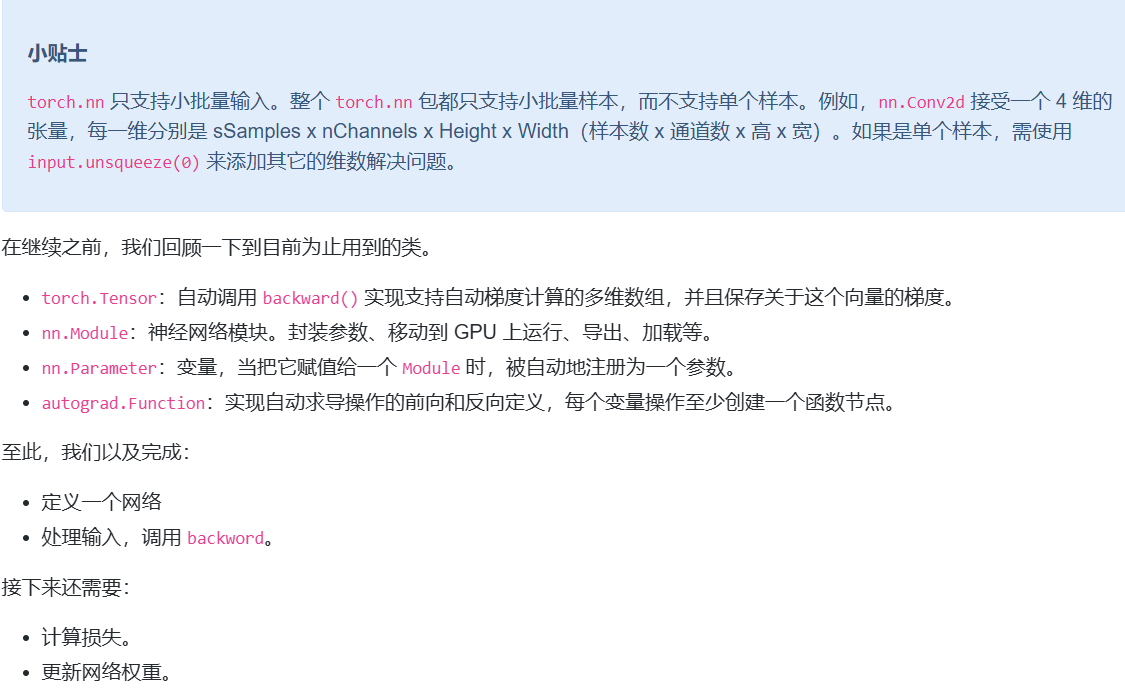

## 损失函数与反向传播 ##

一个损失函数接受一对 (output, target) 作为输入，计算一个值来估计网络的输出和目标值相差多少。

torch.nn 中有很多不同的  损失函数。nn.MSELoss 是一个比较简单的损失函数，它可以用来计算输出和目标间的  均方误差

In [5]:
output = net(input)
target = torch.randn(10)  # 随机值作为样例
target = target.view(1, -1)  # 使 target 和 output 的 shape 相同
criterion = nn.MSELoss()

loss = criterion(output, target)
loss

tensor(0.7789, grad_fn=<MseLossBackward0>)

当我们添加 loss 计算之后，如果使用它 .grad_fn 属性，将得到如下所示的计算图：

input → conv2d → relu → maxpool2d → conv2d → relu → maxpool2d  
      → view → linear → relu → linear → relu → linear  
      → MSELoss  
      → loss  
  
  所以，当我们调用 loss.backward() 时，会针对整个图执行微分操作。图中所有具有 requires_grad=True 的张量的 .grad 梯度会被累积起来。为了说明该情况，我们回溯几个步骤：

In [6]:
print(loss.grad_fn)  # MSELoss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU

调用 loss.backward() 获得反向传播的误差。但是在调用前需要清除已存在的梯度，否则梯度将被累加到已存在的梯度。现在，我们将调用 loss.backward()，并查看 conv1 层的偏差（bias）项在反向传播前后的梯度。下方的代码只能执行一次

In [7]:
net.zero_grad()  # 清除梯度

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0015, -0.0003, -0.0198, -0.0187, -0.0107, -0.0008])


## 更新权重 ##


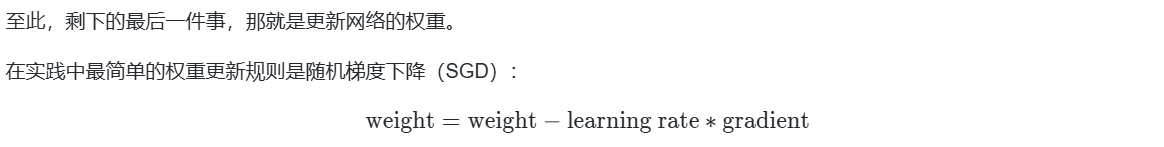

In [8]:
learning_rate = 0.01
for f in net.parameters():
    f.data.sub_(f.grad.data * learning_rate)

当你想使用其他不同的优化方法，如 SGD、Nesterov-SGD、Adam、RMSPROP 等来更新神经网络参数时。可以借助于 PyTorch 中的 torch.optim 快速实现

In [9]:
import torch.optim as optim

# 创建优化器
optimizer = optim.SGD(net.parameters(), lr=0.01)

# 执行一次训练迭代过程
optimizer.zero_grad()  # 梯度置零
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()  # 更新
loss

# 多执行几次，观察损失值的变化情况

tensor(0.7660, grad_fn=<MseLossBackward0>)

## 训练一个分类器 ##


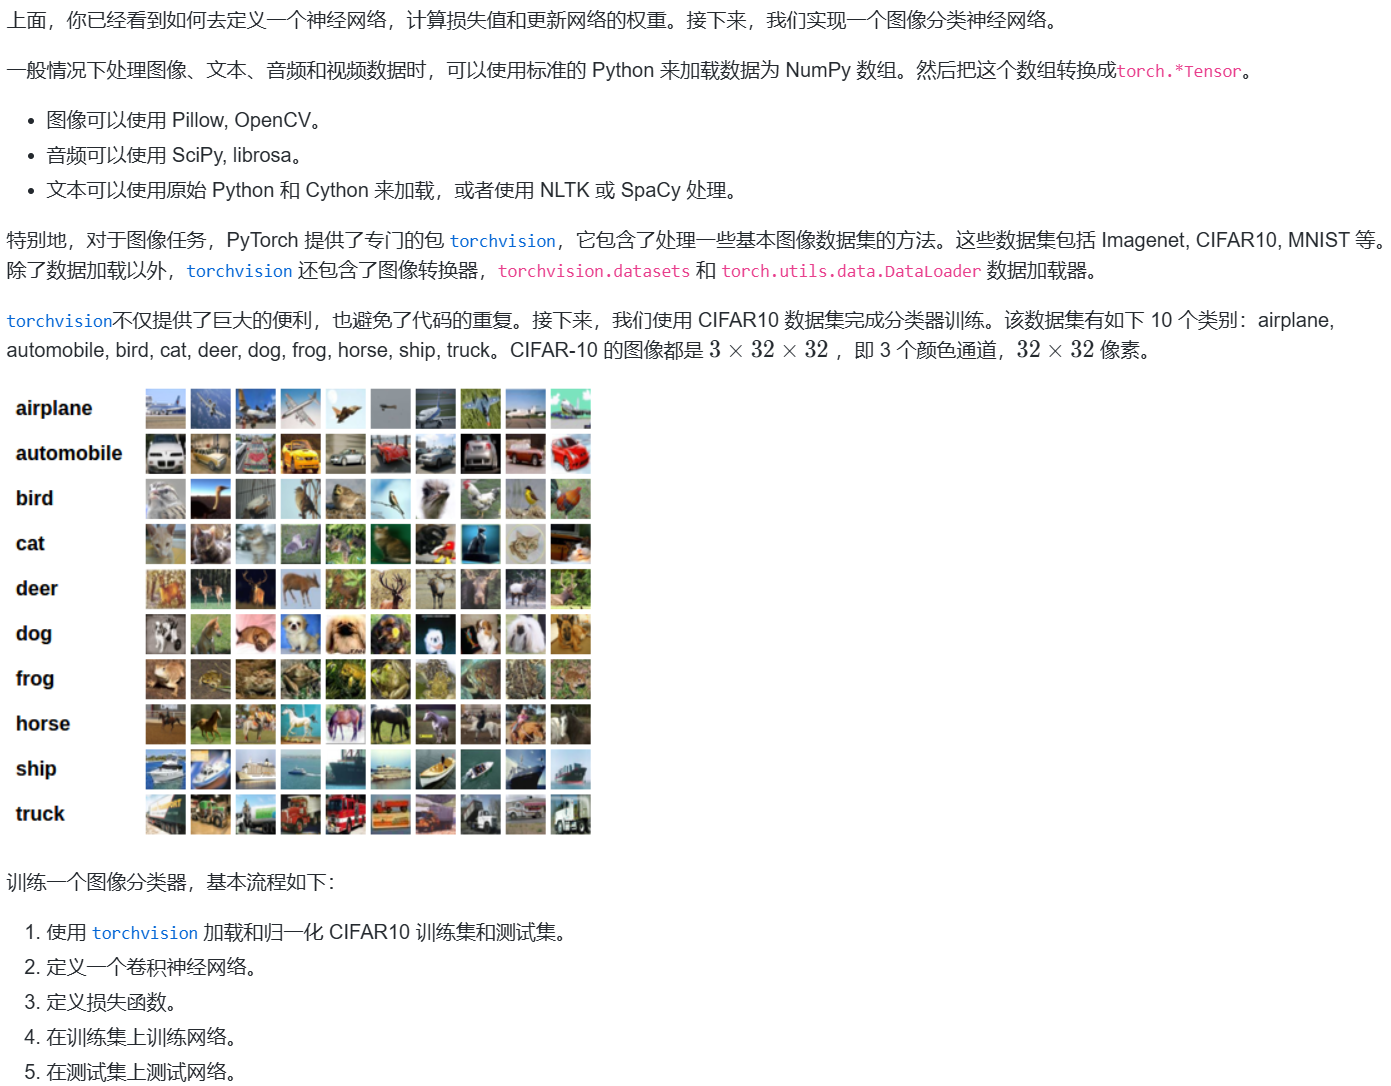

读取和归一化 CIFAR10  
使用 torchvision 可以非常容易地加载 CIFAR10。torchvision 的输出是 [0,1] 的 PILImage 图像，我们把它转换为归一化范围为 [-1, 1] 的张量

In [10]:
import torchvision
import torchvision.transforms as transforms

# 图像预处理步骤
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
# 训练数据加载器
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True, num_workers=2)
# 测试数据加载器
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False, num_workers=2)
# 图像类别
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

trainloader, testloader

Files already downloaded and verified
Files already downloaded and verified


(<torch.utils.data.dataloader.DataLoader at 0x15d4e73fc20>,
 <torch.utils.data.dataloader.DataLoader at 0x15d4adb8680>)

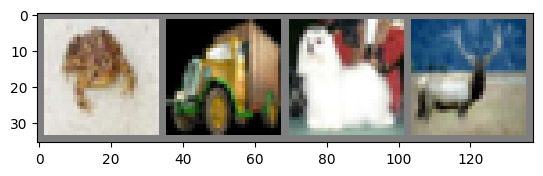

 frog truck   dog  deer


In [11]:
# 可视化
import matplotlib.pyplot as plt
import numpy as np


def imshow(img):
    # 展示图像的函数
    img = img / 2 + 0.5  # 反向归一化
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# 获取随机数据
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 展示图像
imshow(torchvision.utils.make_grid(images))
# 显示图像标签
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))


In [12]:
# 定义一个卷积神经网络

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
net

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [13]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)

In [18]:
# 训练网络
for epoch in range(1):  # 迭代一次
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # 获取输入
        inputs, labels = data
        # 梯度置 0
        optimizer.zero_grad()
        # 正向传播，反向传播，优化
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # 打印状态信息
        running_loss += loss.item()
        if i % 200 == 199:    # 每 200 批次打印一次
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 200))
            running_loss = 0.0
print('Finished Training.')

[1,   200] loss: 1.426
[1,   400] loss: 1.403
[1,   600] loss: 1.417
[1,   800] loss: 1.389
[1,  1000] loss: 1.366
[1,  1200] loss: 1.382
[1,  1400] loss: 1.414
[1,  1600] loss: 1.479
[1,  1800] loss: 1.283
[1,  2000] loss: 1.441
[1,  2200] loss: 1.421
[1,  2400] loss: 1.459
[1,  2600] loss: 1.303
[1,  2800] loss: 1.349
[1,  3000] loss: 1.319
[1,  3200] loss: 1.439
[1,  3400] loss: 1.422
[1,  3600] loss: 1.263
[1,  3800] loss: 1.341
[1,  4000] loss: 1.384
[1,  4200] loss: 1.342
[1,  4400] loss: 1.256
[1,  4600] loss: 1.421
[1,  4800] loss: 1.324
[1,  5000] loss: 1.367
[1,  5200] loss: 1.295
[1,  5400] loss: 1.393
[1,  5600] loss: 1.278
[1,  5800] loss: 1.382
[1,  6000] loss: 1.307
[1,  6200] loss: 1.380
[1,  6400] loss: 1.357
[1,  6600] loss: 1.392
[1,  6800] loss: 1.258
[1,  7000] loss: 1.330
[1,  7200] loss: 1.310
[1,  7400] loss: 1.271
[1,  7600] loss: 1.338
[1,  7800] loss: 1.340
[1,  8000] loss: 1.359
[1,  8200] loss: 1.331
[1,  8400] loss: 1.264
[1,  8600] loss: 1.322
[1,  8800] 

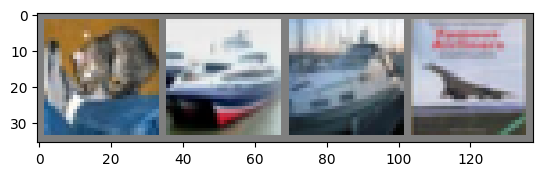

GroundTruth:    cat  ship  ship plane


In [19]:
# 在测试数据上评估网络
dataiter = iter(testloader)
images, labels = next(dataiter)

# 显示图片
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [20]:
outputs = net(images)
outputs

tensor([[-0.9414, -1.5597,  1.6756,  2.6195, -0.8357,  0.7362,  2.1941, -1.6452,
         -0.7815, -1.0453],
        [ 5.1975,  5.2241,  0.1227, -2.1508, -2.4391, -4.0578, -3.7723, -3.9155,
          6.7556,  2.4787],
        [ 3.2931,  2.7524,  0.4100, -1.2995, -1.0614, -2.7323, -2.4438, -1.9407,
          3.5925,  1.5535],
        [ 3.6044,  1.9098,  0.9095, -0.6586, -1.0906, -2.5282, -2.8253, -0.8249,
          3.4218,  0.6223]], grad_fn=<AddmmBackward0>)

In [21]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]] for j in range(4)))

Predicted:    cat  ship  ship plane


In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d%%' %
      (100 * correct / total))
#至少比随机选择要好，随机选择的正确率为 10%。似乎网络学习到了一些东西

Accuracy of the network on the 10000 test images: 55%


In [23]:
# 单个类别的准确率
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    print('Accuracy of %5s : %2d%%' %
          (classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 70%
Accuracy of   car : 62%
Accuracy of  bird : 31%
Accuracy of   cat : 41%
Accuracy of  deer : 38%
Accuracy of   dog : 41%
Accuracy of  frog : 81%
Accuracy of horse : 65%
Accuracy of  ship : 59%
Accuracy of truck : 66%
